Componentes óptimos (95% varianza): 12
Varianza explicada: 95.10%


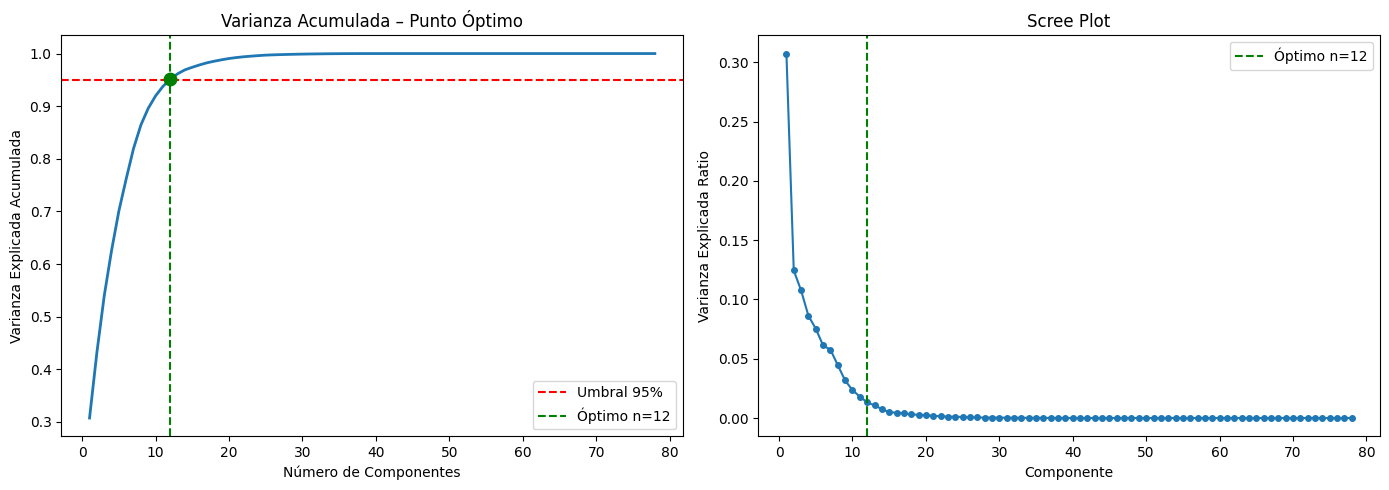


Forma reducida: (1000, 12)  (78 → 12 componentes)
Varianza total explicada: 95.10%


In [7]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_csv('data/clothDataset_36_.csv')

df = df.drop(columns=['frame'])

selected_columns = []
for i in range(6):
    selected_columns.extend([f'x{i}', f'y{i}', f'z{i}', f'sdf{i}'])
df_filtered = df[selected_columns]

# Escalar
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# ── Step 1: Detectar el número óptimo de componentes (umbral 95%) ──
pca_full = PCA()
pca_full.fit(df_scaled)

cumulative_variance = pca_full.explained_variance_ratio_.cumsum()
optimal_n = int(np.argmax(cumulative_variance >= 0.95)) + 1

print(f"Componentes óptimos (95% varianza): {optimal_n}")
print(f"Varianza explicada: {cumulative_variance[optimal_n - 1]:.2%}")

# ── Step 2: Gráfico de varianza acumulada con el punto óptimo marcado ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva acumulada
axes[0].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, linewidth=2)
axes[0].axhline(y=0.95, color='r', linestyle='--', label='Umbral 95%')
axes[0].axvline(x=optimal_n, color='g', linestyle='--', label=f'Óptimo n={optimal_n}')
axes[0].scatter([optimal_n], [cumulative_variance[optimal_n - 1]], color='g', zorder=5, s=80)
axes[0].set_xlabel('Número de Componentes')
axes[0].set_ylabel('Varianza Explicada Acumulada')
axes[0].set_title('Varianza Acumulada – Punto Óptimo')
axes[0].legend()

# Scree plot (varianza individual)
axes[1].plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
             pca_full.explained_variance_ratio_, 'o-', markersize=4)
axes[1].axvline(x=optimal_n, color='g', linestyle='--', label=f'Óptimo n={optimal_n}')
axes[1].set_xlabel('Componente')
axes[1].set_ylabel('Varianza Explicada Ratio')
axes[1].set_title('Scree Plot')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Step 3: Aplicar PCA con el número óptimo ──
pca = PCA(n_components=optimal_n)
df_pca = pca.fit_transform(df_scaled)

print(f"\nForma reducida: {df_pca.shape}  ({df_scaled.shape[1]} → {optimal_n} componentes)")
print(f"Varianza total explicada: {sum(pca.explained_variance_ratio_):.2%}")

In [8]:
# Ver qué features dominan cada componente
# SOLO SI PCA CN 4 FEATURES
"""
import pandas as pd

feature_names = []
for i in range(6):
    feature_names.extend([f'x{i}', f'y{i}', f'z{i}', f'sdf{i}'])

components_df = pd.DataFrame(
    df_pca.components_,
    columns=feature_names,
    index=[f'PC{i+1}' for i in range(optimal_n)]
)

print(components_df.round(3).to_string())
"""

"\nimport pandas as pd\n\nfeature_names = []\nfor i in range(6):\n    feature_names.extend([f'x{i}', f'y{i}', f'z{i}', f'sdf{i}'])\n\ncomponents_df = pd.DataFrame(\n    df_pca.components_,\n    columns=feature_names,\n    index=[f'PC{i+1}' for i in range(optimal_n)]\n)\n\nprint(components_df.round(3).to_string())\n"

Columnas totales usadas para PCA: 78
Componentes PCA óptimos (95% varianza): 12  [varianza explicada: 95.10%]


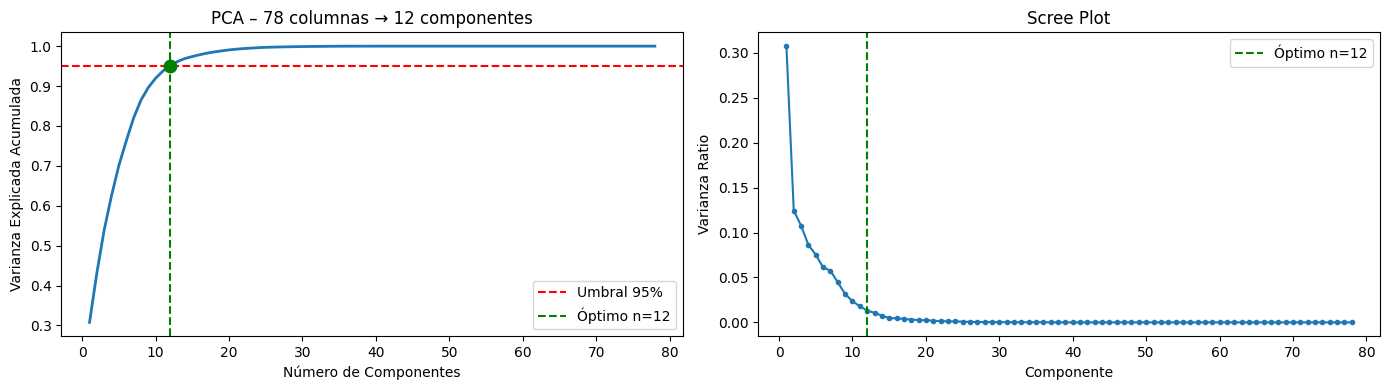

Forma original: (1000, 78)  →  Forma PCA: (1000, 12)
Tensor entrada PCA: torch.Size([1000, 1, 12])  (frames, 1, n_components)
Tensor XYZ real:    torch.Size([1000, 6, 3])   (frames, vertices, 3)


In [9]:
#ADAPTAR DATAFRAME PARA EL RNN
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

num_frames   = df.shape[0]
num_vertices = 6
#num_features = 4  # x, y, z, sdf por vértice

# 3. Datos en 2D para PCA: (frames, vertices * features) = (N, 24)
data_flat_raw = df.values  # (N, 24)

total_columns = data_flat_raw.shape[1]
print(f"Columnas totales usadas para PCA: {total_columns}")

# ── PCA sobre la entrada ──────────────────────────────────────────
# IMPORTANTE: el scaler y el PCA se ajustan sobre TODO el dataset.
# Si divides en train/test, ajústalos SOLO sobre train para evitar
# data leakage (descomenta el bloque de random_split en Cell 6).

input_scaler = StandardScaler()
data_scaled = input_scaler.fit_transform(data_flat_raw)  # (N, 24)

# Detectar n_components óptimo (umbral 95% varianza)
pca_search = PCA()
pca_search.fit(data_scaled)
cumvar = pca_search.explained_variance_ratio_.cumsum()
optimal_n = int(np.argmax(cumvar >= 0.95)) + 1
print(f"Componentes PCA óptimos (95% varianza): {optimal_n}  "
      f"[varianza explicada: {cumvar[optimal_n-1]:.2%}]")

# Scree plot rápido
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(range(1, len(cumvar)+1), cumvar, linewidth=2)
axes[0].axhline(y=0.95, color='r', linestyle='--', label='Umbral 95%')
axes[0].axvline(x=optimal_n, color='g', linestyle='--', label=f'Óptimo n={optimal_n}')
axes[0].scatter([optimal_n], [cumvar[optimal_n-1]], color='g', zorder=5, s=80)
axes[0].set_xlabel('Número de Componentes')
axes[0].set_ylabel('Varianza Explicada Acumulada')
axes[0].set_title(f'PCA – {total_columns} columnas → {optimal_n} componentes')
axes[0].legend()

axes[1].plot(range(1, len(pca_search.explained_variance_ratio_)+1),
             pca_search.explained_variance_ratio_, 'o-', markersize=3)
axes[1].axvline(x=optimal_n, color='g', linestyle='--', label=f'Óptimo n={optimal_n}')
axes[1].set_xlabel('Componente')
axes[1].set_ylabel('Varianza Ratio')
axes[1].set_title('Scree Plot')
axes[1].legend()
plt.tight_layout()
plt.show()

# Ajustar PCA definitivo
input_pca = PCA(n_components=optimal_n)
data_pca  = input_pca.fit_transform(data_scaled)  # (N, optimal_n)

print(f"Forma original: {data_flat_raw.shape}  →  Forma PCA: {data_pca.shape}")

# 4. Guardar las posiciones XYZ originales aparte (para calcular deltas target)
#    Necesitamos XYZ real en el training loop → lo guardamos como tensor separado
xyz_cols = []
for i in range(num_vertices):
    xyz_cols.extend([f'x{i}', f'y{i}', f'z{i}'])
data_xyz = df[xyz_cols].values  # (N, 18)  → 6 vértices × 3 coords
data_xyz_3d = data_xyz.reshape(num_frames, num_vertices, 3)  # (N, 6, 3)
xyz_tensor = torch.tensor(data_xyz_3d, dtype=torch.float32)

# 5. Reshape PCA a 3D para el Dataset: (N, 1, optimal_n)
#    Tratamos cada frame como UN "vértice virtual" con optimal_n features.
#    El modelo recibe secuencias de forma [Batch, Seq, 1, optimal_n].
data_pca_3d  = data_pca.reshape(num_frames, 1, optimal_n)
data_tensor  = torch.tensor(data_pca_3d, dtype=torch.float32)

print(f"Tensor entrada PCA: {data_tensor.shape}  (frames, 1, n_components)")
print(f"Tensor XYZ real:    {xyz_tensor.shape}   (frames, vertices, 3)")


In [10]:
class ClothSequenceDataset(Dataset):
    def __init__(self, pca_frames, xyz_frames, seq_len=5):
        """
        pca_frames : Tensor [Total_Frames, 1, n_components]  – entrada comprimida
        xyz_frames : Tensor [Total_Frames, Vertices, 3]      – posiciones XYZ reales
        seq_len    : frames históricos que usa la RNN
        """
        self.pca_frames = pca_frames if isinstance(pca_frames, torch.Tensor)                           else torch.tensor(pca_frames, dtype=torch.float32)
        self.xyz_frames = xyz_frames if isinstance(xyz_frames, torch.Tensor)                           else torch.tensor(xyz_frames, dtype=torch.float32)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.pca_frames) - self.seq_len

    def __getitem__(self, idx):
        # Secuencia PCA histórica → entrada de la RNN
        # Forma: [Seq_Len, 1, n_components]
        sequence = self.pca_frames[idx : idx + self.seq_len]

        # Frame XYZ del último paso de la secuencia (posición "actual")
        # Forma: [Vertices, 3]
        last_xyz  = self.xyz_frames[idx + self.seq_len - 1]

        # Frame XYZ objetivo (el que hay que predecir)
        # Forma: [Vertices, 3]
        target_xyz = self.xyz_frames[idx + self.seq_len]

        return sequence, last_xyz, target_xyz

# ── Parámetros ────────────────────────────────────────────────────
seq_length = 5
batch_size = 32

dataset = ClothSequenceDataset(data_tensor, xyz_tensor, seq_len=seq_length)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Verificar shapes
for batch_seq, batch_last_xyz, batch_target_xyz in train_loader:
    print(f"Entrada RNN (PCA):  {batch_seq.shape}")
    # → [Batch, Seq_Len, 1, n_components]
    print(f"Última pos XYZ:     {batch_last_xyz.shape}")
    # → [Batch, Vertices, 3]
    print(f"Target XYZ:         {batch_target_xyz.shape}")
    # → [Batch, Vertices, 3]
    break

Entrada RNN (PCA):  torch.Size([32, 5, 1, 12])
Última pos XYZ:     torch.Size([32, 6, 3])
Target XYZ:         torch.Size([32, 6, 3])


In [11]:
import torch
import torch.nn as nn

class FlatRNNClothUnity(nn.Module):
    def __init__(self, n_pca_components, num_vertices, hidden_size, num_outputs=3):
        """
        n_pca_components : número de componentes PCA (entrada comprimida por frame)
        num_vertices     : vértices del tejido (para reconstruir la salida)
        hidden_size      : tamaño del estado oculto de la RNN
        num_outputs      : coordenadas a predecir por vértice (3 → delta XYZ)
        """
        super(FlatRNNClothUnity, self).__init__()

        self.num_vertices = num_vertices
        self.num_outputs  = num_outputs

        # La entrada por frame es el vector PCA aplanado (1 × n_pca_components)
        self.input_size = n_pca_components

        self.rnn_cell = nn.RNNCell(
            input_size=self.input_size,
            hidden_size=hidden_size,
            nonlinearity='relu'
        )

        # Salida: delta XYZ para cada vértice (en espacio original)
        self.fc = nn.Linear(hidden_size, num_vertices * num_outputs)

    def forward(self, x):
        # x: [Batch, Seq_Len, 1, n_pca_components]
        batch_size = x.size(0)
        seq_len    = x.size(1)

        # Aplanar dimensión de vértices (solo hay 1): [Batch, Seq_Len, n_pca_components]
        x_flat = x.view(batch_size, seq_len, -1)

        h_t = torch.zeros(batch_size, self.rnn_cell.hidden_size, device=x.device)
        for t in range(seq_len):
            h_t = self.rnn_cell(x_flat[:, t, :], h_t)

        # Proyección a delta XYZ
        pred_flat  = self.fc(h_t)                                   # [Batch, Vertices*3]
        pred_delta = pred_flat.view(batch_size, self.num_vertices, self.num_outputs)
        return pred_delta  # [Batch, Vertices, 3]  – delta XYZ real


In [12]:
import torch
from torch.utils.data import random_split, DataLoader
import json
import numpy as np

# ==============================================================================
# 1. SPLIT THE DATA (80% Training, 20% Testing)
# ==============================================================================
"""
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

#TODO: vigilar esto!!!
# Nota: Al usar random_split, mezclamos secuencias de 5 frames de forma aleatoria.
# Esto suele funcionar bien, aunque para algunos problemas físicos puristas a veces 
# se divide cronológicamente (ej. primeros 80% frames para train, últimos 20% para test).
# Por ahora mantendremos random_split que es el enfoque estándar general.
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
"""
train_dataset, test_dataset = dataset, dataset

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# ==============================================================================
# 2. COMPUTE GLOBAL STATS
# ==============================================================================
# La entrada ya está normalizada vía StandardScaler + PCA.
# Solo necesitamos normalizar los deltas objetivo.
all_target_deltas = []
for _, batch_last_xyz, batch_target_xyz in train_loader:
    delta = batch_target_xyz - batch_last_xyz   # [Batch, Vertices, 3]
    all_target_deltas.append(delta.view(-1, 3))

full_target_tensor = torch.cat(all_target_deltas, dim=0)
target_mean = full_target_tensor.mean(dim=0)   # [3]
target_std  = full_target_tensor.std(dim=0)    # [3]
print("target_mean:", target_mean)
print("target_std: ", target_std)

# ==============================================================================
# 3. SAVE TO JSON
# ==============================================================================
import pickle
norm_data = {
    "input_scaler_mean": input_scaler.mean_.tolist(),
    "input_scaler_std":  input_scaler.scale_.tolist(),
    "pca_components":    input_pca.components_.flatten().tolist(),
    "pca_mean":          input_pca.mean_.tolist(),
    "target_mean":       target_mean.tolist(),
    "target_std":        target_std.tolist(),
    "optimal_n":         optimal_n,
    "num_vertices":      6,
}
with open("todoPCA_norm_params.json", "w") as f:
    json.dump(norm_data, f)
print("Parámetros guardados en todoPCA_norm_params.json")

# ==============================================================================
# 4. SETUP MODEL
# ==============================================================================
model     = FlatRNNClothUnity(n_pca_components=optimal_n, num_vertices=6,
                               hidden_size=128, num_outputs=3)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

print(f"\nModelo creado | input_size={optimal_n} | "
      f"output={6*3} (6 vértices × 3 coords XYZ)")

print(input_pca.components_.shape)

target_mean: tensor([-1.4412e-04,  2.1187e-05,  6.6167e-08])
target_std:  tensor([0.0831, 0.0284, 0.0087])
Parámetros guardados en todoPCA_norm_params.json

Modelo creado | input_size=12 | output=18 (6 vértices × 3 coords XYZ)
(12, 78)


In [13]:
# ==============================================================================
# 5. TRAINING & TESTING LOOP
# ==============================================================================
epochs = 500
for epoch in range(epochs):
    
    # --- TRAINING PHASE ---
    model.train() 
    noise_scale = 0.05
    train_loss = 0.0
    
    for batch_seq, batch_last_xyz, batch_target_xyz in train_loader:
        batch_seq        = batch_seq.float()
        batch_last_xyz   = batch_last_xyz.float()
        batch_target_xyz = batch_target_xyz.float()

        # Ruido sobre la entrada PCA (ya normalizada)
        noise = torch.randn_like(batch_seq) * noise_scale
        batch_seq_noisy = batch_seq + noise

        # Delta objetivo normalizado
        target_delta      = batch_target_xyz - batch_last_xyz      # [B, V, 3]
        target_delta_norm = (target_delta - target_mean) / target_std
        
        # 3. Predicción
        pred_delta_norm = model(batch_seq_noisy)
        
        # 4. Retropropagación
        loss = criterion(pred_delta_norm, target_delta_norm)
    
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    print(f'Train Epoch {epoch+1:03d}')

    avg_train_loss = train_loss / len(train_loader)

    # --- TESTING/VALIDATION PHASE ---
    model.eval() 
    test_loss = 0.0
    total_distance_error = 0.0
    total_vertices = 0

    all_pred_deltas  = []
    all_target_deltas_eval = []
    all_pred_pos     = []
    all_target_pos   = []
    
    with torch.no_grad():
        for batch_seq, batch_last_xyz, batch_target_xyz in test_loader:
            batch_seq        = batch_seq.float()
            batch_last_xyz   = batch_last_xyz.float()
            batch_target_xyz = batch_target_xyz.float()

            pred_delta_norm   = model(batch_seq)
            target_delta      = batch_target_xyz - batch_last_xyz
            target_delta_norm = (target_delta - target_mean) / target_std

            loss = criterion(pred_delta_norm, target_delta_norm)
            test_loss += loss.item()

            # Reconstruir posiciones absolutas
            pred_delta_real = (pred_delta_norm * target_std) + target_mean
            pred_pos        = batch_last_xyz + pred_delta_real
            target_pos      = batch_target_xyz

            all_pred_pos.append(pred_pos.cpu().numpy())
            all_target_pos.append(target_pos.cpu().numpy())

            distances = torch.norm(pred_delta_real - target_delta, dim=-1)
            total_distance_error += distances.sum().item()
            total_vertices       += distances.numel()

            all_pred_deltas.append(pred_delta_real.cpu().numpy())
            all_target_deltas_eval.append(target_delta.cpu().numpy())

    avg_test_loss = test_loss / len(test_loader)
    avg_distance_error = total_distance_error / total_vertices

    # Combine into large arrays
    preds_pos_np = np.concatenate(all_pred_pos, axis=0)
    targets_pos_np = np.concatenate(all_target_pos, axis=0)

    # Reusar nombre para compatibilidad con celdas de visualización
    all_pred_deltas  = all_pred_deltas
    all_target_deltas = all_target_deltas_eval

    print(f"Epoch {epoch+1:03d} | Train: {avg_train_loss:.6f} | "
          f"Test: {avg_test_loss:.6f} | Vertex Error: {avg_distance_error:.6f} units")


Train Epoch 001
Epoch 001 | Train: 0.599937 | Test: 0.588158 | Vertex Error: 0.061271 units
Train Epoch 002
Epoch 002 | Train: 0.580466 | Test: 0.572798 | Vertex Error: 0.059514 units
Train Epoch 003
Epoch 003 | Train: 0.566772 | Test: 0.560180 | Vertex Error: 0.057989 units
Train Epoch 004
Epoch 004 | Train: 0.554420 | Test: 0.547774 | Vertex Error: 0.056402 units
Train Epoch 005
Epoch 005 | Train: 0.541558 | Test: 0.534209 | Vertex Error: 0.054556 units
Train Epoch 006
Epoch 006 | Train: 0.526736 | Test: 0.517778 | Vertex Error: 0.052221 units
Train Epoch 007
Epoch 007 | Train: 0.507813 | Test: 0.495808 | Vertex Error: 0.048916 units
Train Epoch 008
Epoch 008 | Train: 0.481575 | Test: 0.463968 | Vertex Error: 0.043906 units
Train Epoch 009
Epoch 009 | Train: 0.443754 | Test: 0.421403 | Vertex Error: 0.037365 units
Train Epoch 010
Epoch 010 | Train: 0.404120 | Test: 0.386691 | Vertex Error: 0.032656 units
Train Epoch 011
Epoch 011 | Train: 0.375995 | Test: 0.363458 | Vertex Error: 0.0

Componentes óptimos para visualización post-entrenamiento: 4
Varianza explicada (targets): 96.49%


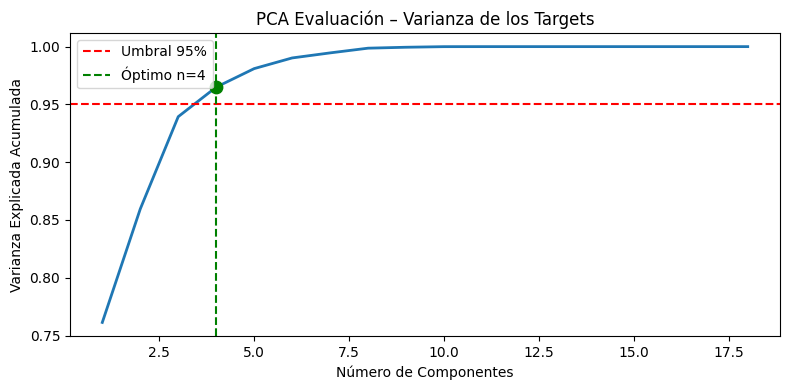

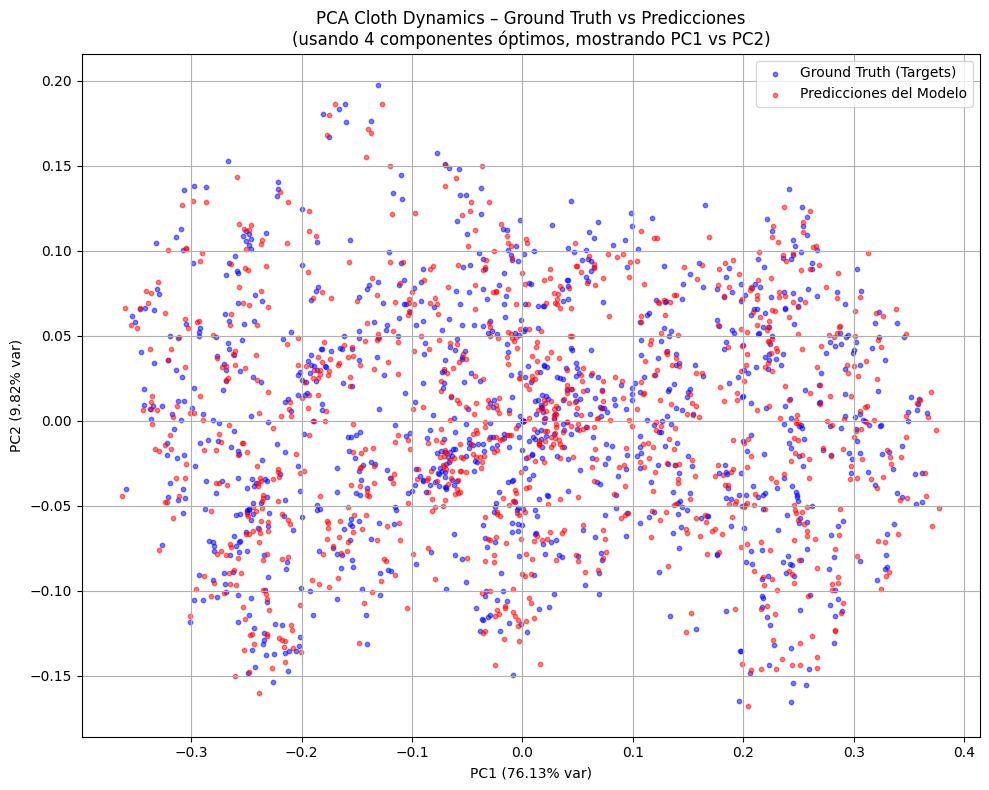

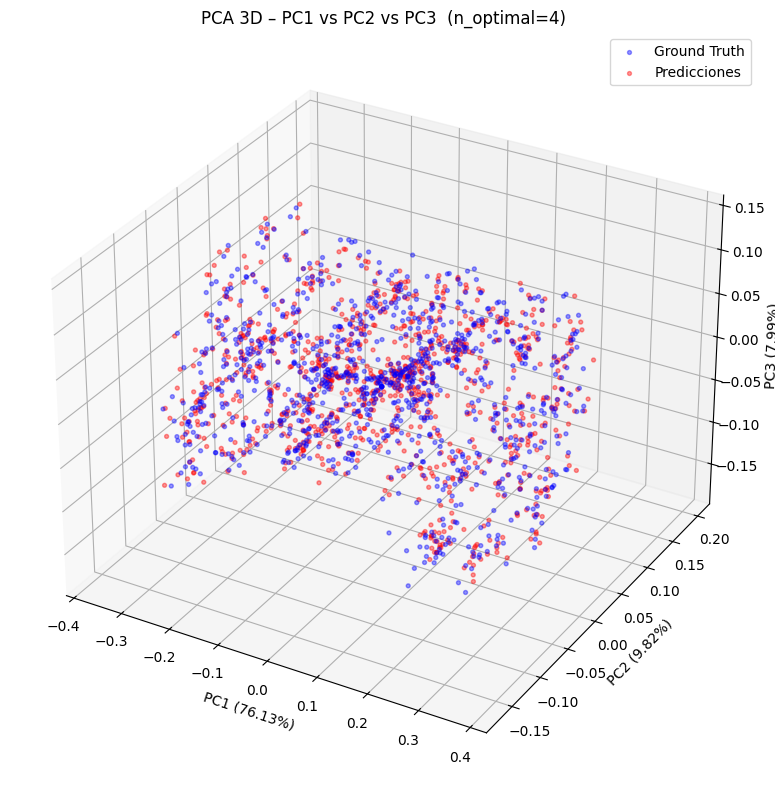

Vista 3D generada (PC1, PC2, PC3)


In [14]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# 1. Combinar los batches recogidos en arrays únicos
preds_np   = np.concatenate(all_pred_deltas,  axis=0)  # (Total_Frames, Vertices, 3)
targets_np = np.concatenate(all_target_deltas, axis=0) # (Total_Frames, Vertices, 3)

# 2. Reshape a 2D: (Total_Frames, Vertices * 3)
preds_2d   = preds_np.reshape(preds_np.shape[0], -1)
targets_2d = targets_np.reshape(targets_np.shape[0], -1)

# ── Detectar número óptimo de componentes sobre los targets ──
pca_full = PCA()
pca_full.fit(targets_2d)
cumvar = pca_full.explained_variance_ratio_.cumsum()
optimal_n_eval = int(np.argmax(cumvar >= 0.95)) + 1
optimal_n_eval = min(optimal_n_eval, targets_2d.shape[1])  # no puede superar las features

print(f"Componentes óptimos para visualización post-entrenamiento: {optimal_n_eval}")
print(f"Varianza explicada (targets): {cumvar[optimal_n_eval - 1]:.2%}")

# ── Gráfico de varianza para la evaluación ──
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar) + 1), cumvar, linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='Umbral 95%')
plt.axvline(x=optimal_n_eval, color='g', linestyle='--', label=f'Óptimo n={optimal_n_eval}')
plt.scatter([optimal_n_eval], [cumvar[optimal_n_eval - 1]], color='g', zorder=5, s=80)
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('PCA Evaluación – Varianza de los Targets')
plt.legend()
plt.tight_layout()
plt.show()

# ── Ajustar PCA sobre targets (espacio compartido) y transformar ambos ──
pca_eval = PCA(n_components=optimal_n_eval)
pca_eval.fit(targets_2d)
pca_targets = pca_eval.transform(targets_2d)
pca_preds   = pca_eval.transform(preds_2d)

# ── Visualización: siempre 2D con PC1 vs PC2 ──
plt.figure(figsize=(10, 8))
plt.scatter(pca_targets[:, 0], pca_targets[:, 1],
            alpha=0.5, label='Ground Truth (Targets)', color='blue', s=10)
plt.scatter(pca_preds[:, 0],   pca_preds[:, 1],
            alpha=0.5, label='Predicciones del Modelo', color='red',  s=10)
plt.title(f'PCA Cloth Dynamics – Ground Truth vs Predicciones\n'
          f'(usando {optimal_n_eval} componentes óptimos, mostrando PC1 vs PC2)')
plt.xlabel(f'PC1 ({pca_eval.explained_variance_ratio_[0]:.2%} var)')
plt.ylabel(f'PC2 ({pca_eval.explained_variance_ratio_[1]:.2%} var)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Si hay 3+ componentes, añadir vista 3D ──
if optimal_n_eval >= 3:
    from mpl_toolkits.mplot3d import Axes3D
    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(pca_targets[:, 0], pca_targets[:, 1], pca_targets[:, 2],
               alpha=0.4, label='Ground Truth', color='blue', s=8)
    ax.scatter(pca_preds[:, 0],   pca_preds[:, 1],   pca_preds[:, 2],
               alpha=0.4, label='Predicciones',  color='red',  s=8)
    ax.set_title(f'PCA 3D – PC1 vs PC2 vs PC3  (n_optimal={optimal_n_eval})')
    ax.set_xlabel(f'PC1 ({pca_eval.explained_variance_ratio_[0]:.2%})')
    ax.set_ylabel(f'PC2 ({pca_eval.explained_variance_ratio_[1]:.2%})')
    ax.set_zlabel(f'PC3 ({pca_eval.explained_variance_ratio_[2]:.2%})')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print("Vista 3D generada (PC1, PC2, PC3)")
else:
    print("Solo 2 componentes óptimos – se muestra únicamente la vista 2D.")

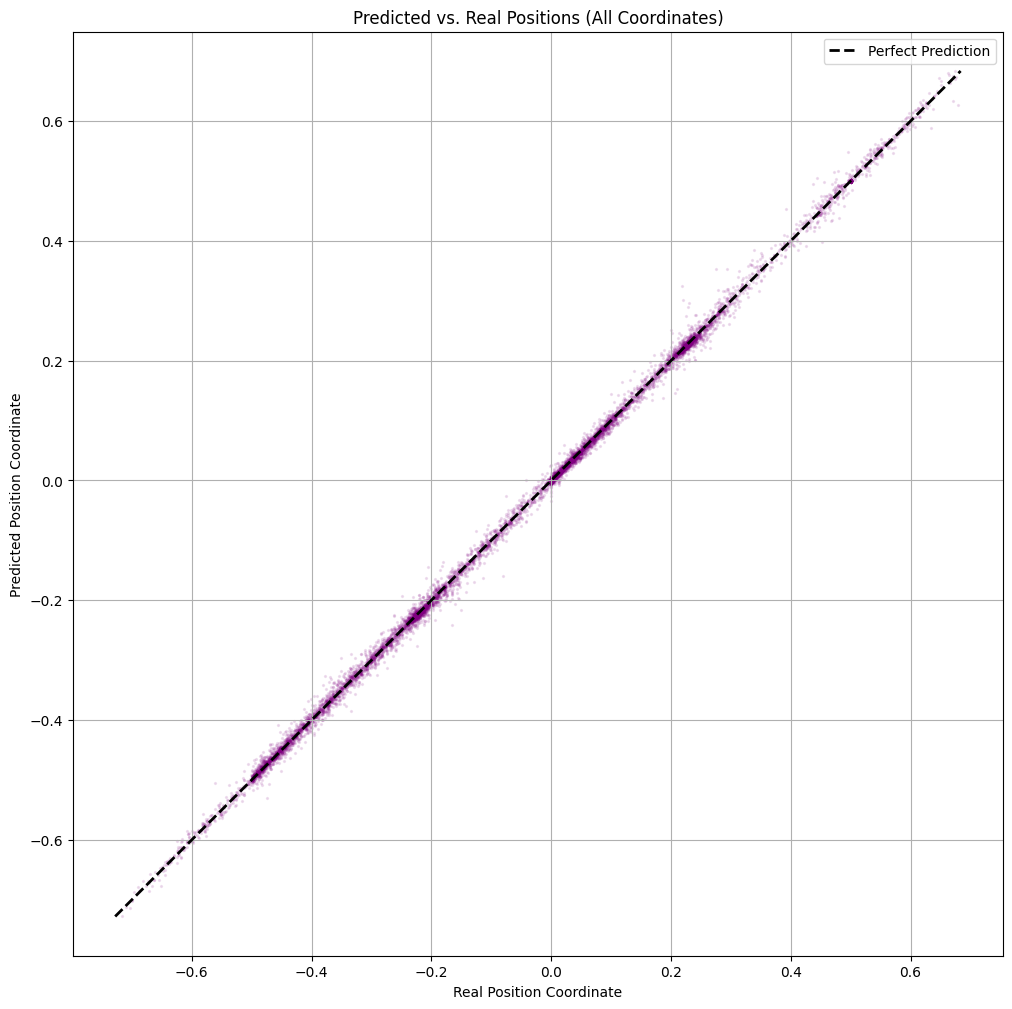

In [15]:
import matplotlib.pyplot as plt

# Flatten the arrays so we just have a massive list of X, Y, and Z coordinates
true_flat = targets_pos_np.reshape(-1)
pred_flat = preds_pos_np.reshape(-1)

plt.figure(figsize=(12, 12))
plt.scatter(true_flat, pred_flat, alpha=0.1, color='purple', s=2)

# Draw the perfect prediction line (y = x)
min_val = min(true_flat.min(), pred_flat.min())
max_val = max(true_flat.max(), pred_flat.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Predicted vs. Real Positions (All Coordinates)')
plt.xlabel('Real Position Coordinate')
plt.ylabel('Predicted Position Coordinate')
plt.legend()
plt.grid(True)
plt.axis('equal') # Keeps the aspect ratio square
plt.show()

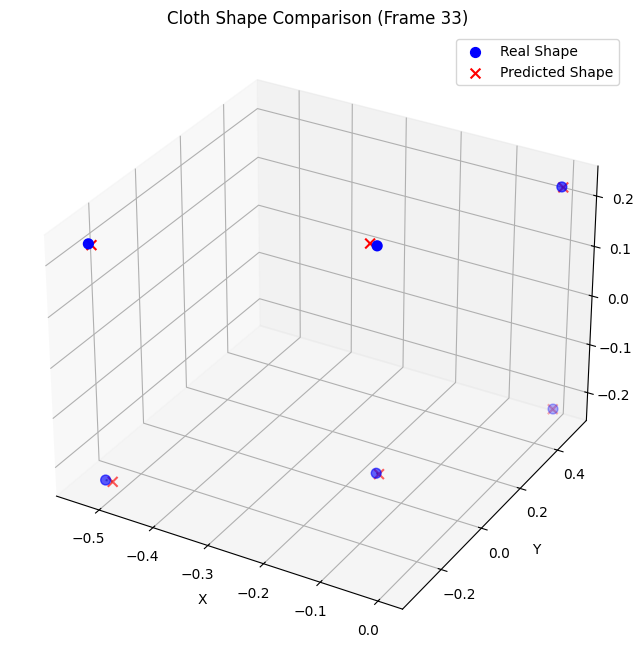

In [16]:
# Choose a random frame from your test set to visualize
frame_idx = 33 # Change this to look at different moments
num_vertices = targets_pos_np.shape[1]

real_frame = targets_pos_np[frame_idx] # Shape: (Vertices, 3)
pred_frame = preds_pos_np[frame_idx]   # Shape: (Vertices, 3)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Extract X, Y, Z for Real positions
rx, ry, rz = real_frame[:, 0], real_frame[:, 1], real_frame[:, 2]
# Extract X, Y, Z for Predicted positions
px, py, pz = pred_frame[:, 0], pred_frame[:, 1], pred_frame[:, 2]

# Plot the real cloth vertices in Blue
ax.scatter(rx, ry, rz, c='blue', label='Real Shape', s=50, marker='o')

# Plot the predicted cloth vertices in Red
ax.scatter(px, py, pz, c='red', label='Predicted Shape', s=50, marker='x')

# Draw lines connecting the predicted vertex to the real vertex to show the error
for i in range(num_vertices):
    ax.plot([rx[i], px[i]], [ry[i], py[i]], [rz[i], pz[i]], color='gray', linestyle='dotted')

ax.set_title(f'Cloth Shape Comparison (Frame {frame_idx})')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

In [17]:
import torch
import sys
import onnx
import onnxruntime

# 1. Load your trained model (make sure it's in eval mode)
model.eval()

# 2. NUEVO: Creamos el dummy input con 4 dimensiones: 
# [Batch=1, Seq_Len=5, Vertice virtual=1, FeaturesPCA=optimal_n]
dummy_input = torch.randn(1, 5, 1, optimal_n)

# 3. Export to ONNX (el resto se mantiene igual)
onnx_program = torch.onnx.export(
    model,                      
    dummy_input,                # Tu [1, 5, 1, optimal_n]
    "todo_PCA_rnn.onnx", 
    export_params=True,         
    opset_version=15,           # <--- Subir a 15
    input_names=['input'],      
    output_names=['output'],    
)

print("Exported to ONNX with strict 4D sequential shapes!")

Exported to ONNX with strict 4D sequential shapes!
